In [1]:
#Load & Guarantee Datetime Index
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

# Load engineered features
df = pd.read_parquet("../data/processed/accra_features_2024.parquet")

# ── CRITICAL: Ensure datetime index ──────────────────────────────────
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
else:
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

print("── Index type  :", type(df.index))
print("── Index dtype :", df.index.dtype)
print("── Date range  :", df.index.min().date(), "→", df.index.max().date())
print("── Shape       :", df.shape)
print("── Null count  :\n", df.isnull().sum())
print("\n── Preview ──")
print(df.head(10).to_string())

── Index type  : <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
── Index dtype : datetime64[ns]
── Date range  : 2024-01-01 → 2024-12-30
── Shape       : (365, 12)
── Null count  :
 precipitation       0
rainfall_class      0
roll_7d             0
roll_30d            0
cumulative          0
z_score             0
is_anomaly          0
is_wet              0
wet_spell_id        0
roll_3d             0
flood_risk_score    0
risk_tier           0
dtype: int64

── Preview ──
            precipitation rainfall_class   roll_7d  roll_30d  cumulative   z_score  is_anomaly  is_wet  wet_spell_id   roll_3d  flood_risk_score   risk_tier
date                                                                                                                                                        
2024-01-01       0.000000            Dry  0.000000  0.000000    0.000000  0.000000       False   False             1  0.000000              0.00       🟢 Low
2024-01-02       0.037781          Light  0.0188

In [2]:
#Prepare ML Features
feature_columns = [
    "precipitation",
    "roll_3d",
    "roll_7d",
    "roll_30d",
    "cumulative",
    "z_score",
]

target_column = "flood_risk_score"

# Drop rows with nulls in relevant columns only
df_model = df[feature_columns + [target_column]].dropna()

X = df_model[feature_columns]
y = df_model[target_column]

print(f"✅ Features shape : {X.shape}")
print(f"✅ Target shape   : {y.shape}")
print(f"\n── Target Distribution ──")
print(y.describe().round(2))

✅ Features shape : (365, 6)
✅ Target shape   : (365,)

── Target Distribution ──
count    365.00
mean      12.58
std       17.93
min        0.00
25%        0.16
50%        4.89
75%       16.85
max       92.57
Name: flood_risk_score, dtype: float64


In [3]:
#Temporal Train/Test Split (with index guard)
# ── CRITICAL: Confirm index is datetime before filtering ──────────────
assert pd.api.types.is_datetime64_any_dtype(X.index), \
    "❌ Index is not datetime — run Step 1 fix first."

split_date = "2024-09-01"

X_train = X[X.index < split_date]
X_test  = X[X.index >= split_date]
y_train = y[y.index < split_date]
y_test  = y[y.index >= split_date]

print(f"✅ Train : {len(X_train)} days  ({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"✅ Test  : {len(X_test)}  days  ({X_test.index.min().date()} → {X_test.index.max().date()})")
print(f"\n── Risk Score Distribution ──")
print(f"   Train mean : {y_train.mean():.2f}")
print(f"   Test  mean : {y_test.mean():.2f}")

✅ Train : 244 days  (2024-01-01 → 2024-08-31)
✅ Test  : 121  days  (2024-09-01 → 2024-12-30)

── Risk Score Distribution ──
   Train mean : 13.49
   Test  mean : 10.75


In [4]:
#Train XGBoost + Overfit Detection
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

# ── Model Summary ─────────────────────────────────────────────────────
print(model)

# ── Overfit Detection ─────────────────────────────────────────────────
train_r2 = model.score(X_train, y_train)
test_r2  = model.score(X_test,  y_test)
gap      = train_r2 - test_r2

print(f"\n── Overfitting Check ─────────────────────────")
print(f"   Train R² : {train_r2:.3f}")
print(f"   Test  R² : {test_r2:.3f}")
print(f"   Gap      : {gap:.3f}")

if gap < 0.05:
    print("   🟢 No overfitting detected")
elif gap < 0.15:
    print("   🟡 Mild overfitting — monitor closely")
else:
    print("   🔴 Overfitting detected — reduce max_depth or add regularisation")

print("\n✅ XGBoost flood-risk model trained")

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

── Overfitting Check ─────────────────────────
   Train R² : 1.000
   Test  R² : 0.993
   Gap      : 0.007
   🟢 No overfitting detected

✅ XGBoost flood-risk model trained


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = np.clip(model.predict(X_test), 0, 100)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))   # ← fixed
r2   = r2_score(y_test, y_pred)

print("── Model Evaluation ──────────────────────────")
print(f"   MAE  : {mae:.2f}  (avg prediction error in risk points)")
print(f"   RMSE : {rmse:.2f}  (penalises large errors)")
print(f"   R²   : {r2:.3f}  (target > 0.70 for production)")
print("──────────────────────────────────────────────")

if r2 >= 0.85:
    print("🟢 Excellent model performance")
elif r2 >= 0.70:
    print("🟡 Good model performance — production ready")
else:
    print("🔴 Model needs improvement — consider more features")

# Results table
results_df = pd.DataFrame({
    "actual_risk"    : y_test.values,
    "predicted_risk" : y_pred,
    "error"          : abs(y_test.values - y_pred),
}, index=y_test.index)

print(f"\n── Top 10 Highest Risk Days (Predicted) ──")
print(results_df.nlargest(10, "predicted_risk").round(2).to_string())

── Model Evaluation ──────────────────────────
   MAE  : 0.85  (avg prediction error in risk points)
   RMSE : 1.30  (penalises large errors)
   R²   : 0.993  (target > 0.70 for production)
──────────────────────────────────────────────
🟢 Excellent model performance

── Top 10 Highest Risk Days (Predicted) ──
            actual_risk  predicted_risk  error
date                                          
2024-10-08        69.94       68.209999   1.73
2024-10-29        62.95       65.410004   2.46
2024-11-15        64.68       63.090000   1.59
2024-10-13        58.47       61.380001   2.91
2024-10-05        57.99       52.689999   5.30
2024-10-09        48.14       48.580002   0.44
2024-10-26        42.32       43.320000   1.00
2024-10-03        41.44       42.270000   0.83
2024-09-14        44.70       38.169998   6.53
2024-09-11        38.39       35.130001   3.26


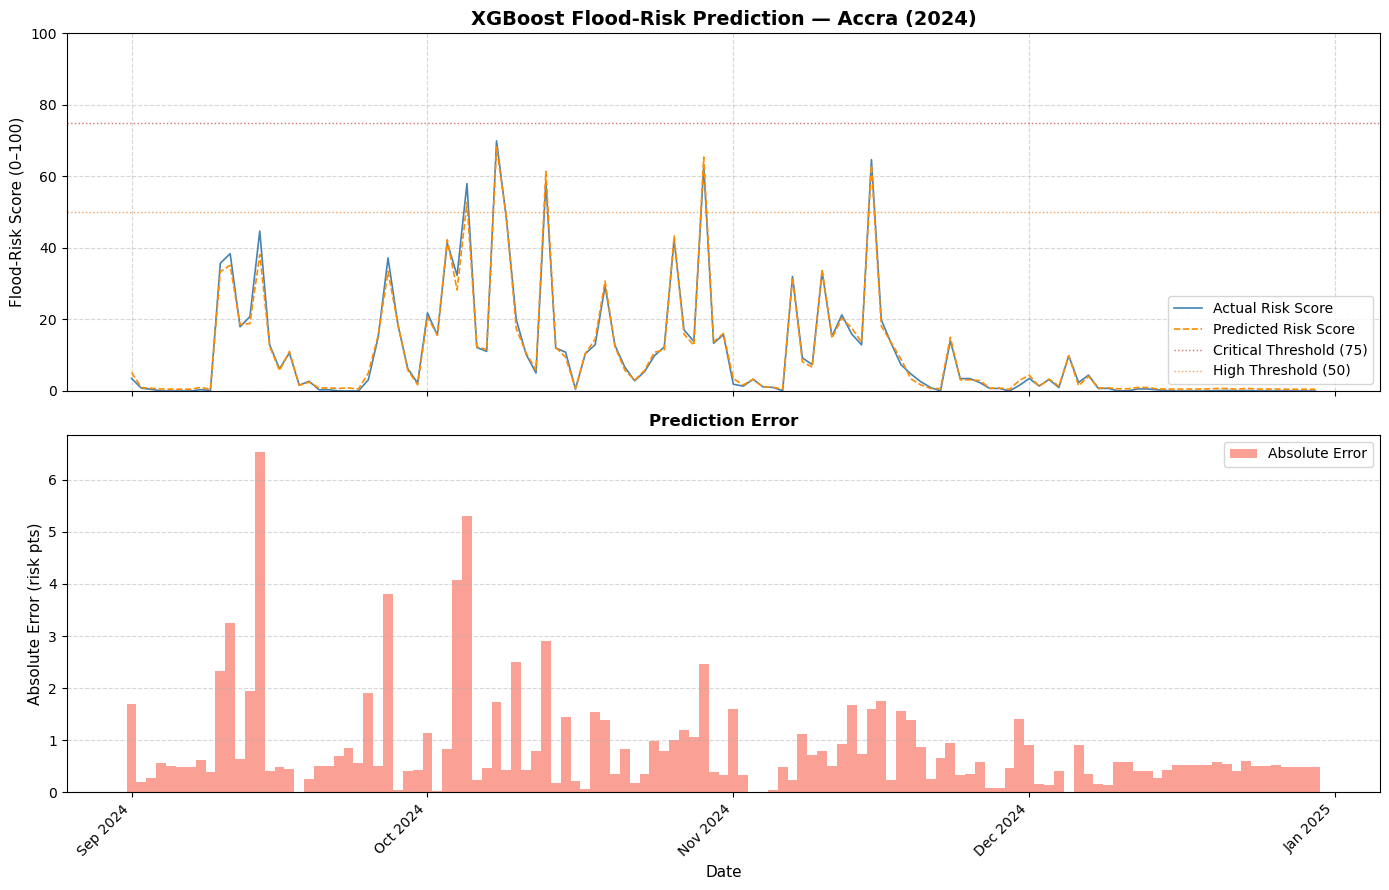

In [8]:
#Prediction vs Actual Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(results_df.index, results_df["actual_risk"],
             color="steelblue", linewidth=1.2, label="Actual Risk Score")
axes[0].plot(results_df.index, results_df["predicted_risk"],
             color="darkorange", linewidth=1.2,
             linestyle="--", label="Predicted Risk Score")
axes[0].axhline(y=75, color="#c0392b", linestyle=":", linewidth=1.0,
                alpha=0.7, label="Critical Threshold (75)")
axes[0].axhline(y=50, color="#e67e22", linestyle=":", linewidth=1.0,
                alpha=0.7, label="High Threshold (50)")
axes[0].set_title("XGBoost Flood-Risk Prediction — Accra (2024)",
                  fontsize=14, fontweight="bold")
axes[0].set_ylabel("Flood-Risk Score (0–100)", fontsize=11)
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].bar(results_df.index, results_df["error"],
            color="salmon", alpha=0.75, width=1.0, label="Absolute Error")
axes[1].set_title("Prediction Error", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Absolute Error (risk pts)", fontsize=11)
axes[1].set_xlabel("Date", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, axis="y", linestyle="--", alpha=0.5)

axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../data/processed/accra_xgb_predictions_2024.png",
            dpi=150, bbox_inches="tight")
plt.show()

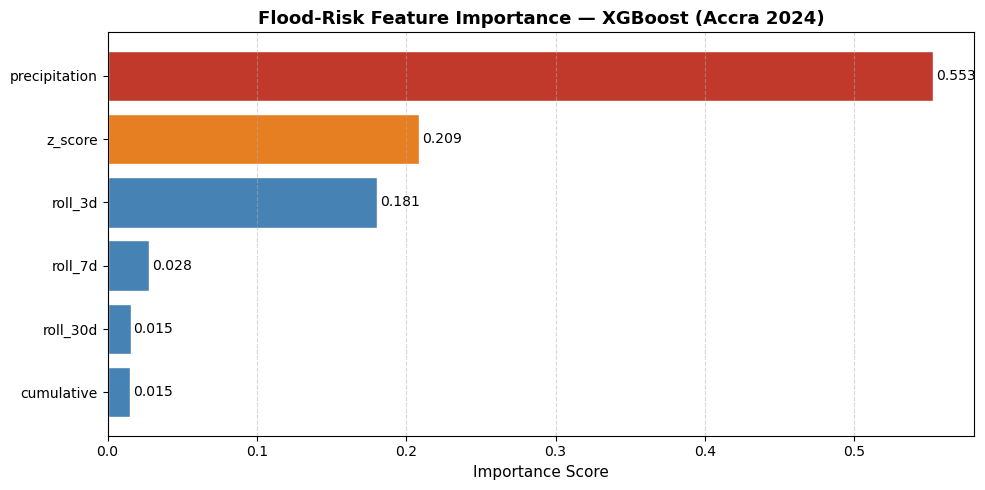


── Feature Importance Ranking ──
   precipitation        0.5528
   z_score              0.2088
   roll_3d              0.1805
   roll_7d              0.0276
   roll_30d             0.0154
   cumulative           0.0149


In [12]:
importance = pd.Series(
    model.feature_importances_,
    index=feature_columns
).sort_values(ascending=True)

colors = [
    "#c0392b" if imp == importance.max() else
    "#e67e22" if imp >= importance.quantile(0.75) else
    "steelblue"
    for imp in importance
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(importance.index, importance.values,
               color=colors, edgecolor="white")

for bar, val in zip(bars, importance.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=10)

ax.set_title("Flood-Risk Feature Importance — XGBoost (Accra 2024)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score", fontsize=11)
ax.grid(True, axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../data/processed/accra_feature_importance_2024.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\n── Feature Importance Ranking ──")
for feat, score in importance.sort_values(ascending=False).items():
    print(f"   {feat:<20} {score:.4f}")

In [13]:
#Save Model & Live Inference Test
os.makedirs("../models", exist_ok=True)

model_path = "../models/xgboost_flood_risk.pkl"
joblib.dump(model, model_path)
print(f"✅ Model saved → {model_path}")

# ── Live Inference Test ───────────────────────────────────────────────
sample_input = pd.DataFrame([{
    "precipitation" : 28.5,
    "roll_3d"       : 55.2,
    "roll_7d"       : 18.3,
    "roll_30d"      : 9.1,
    "cumulative"    : 620.0,
    "z_score"       : 2.8,
}])

live_score = np.clip(model.predict(sample_input)[0], 0, 100)

def risk_tier(score):
    if score >= 75: return "🔴 CRITICAL"
    elif score >= 50: return "🟠 HIGH"
    elif score >= 25: return "🟡 MODERATE"
    return "🟢 LOW"

print(f"\n── Live Inference Test ──────────────────────")
print(f"   Score : {live_score:.1f} / 100")
print(f"   Tier  : {risk_tier(live_score)}")
print(f"────────────────────────────────────────────")
print(f"\n✅ Phase 3A complete — XGBoost model trained, evaluated, saved.")
print(f"✅ Ready for Phase 3B — Streamlit NFCC Dashboard.")

✅ Model saved → ../models/xgboost_flood_risk.pkl

── Live Inference Test ──────────────────────
   Score : 81.9 / 100
   Tier  : 🔴 CRITICAL
────────────────────────────────────────────

✅ Phase 3A complete — XGBoost model trained, evaluated, saved.
✅ Ready for Phase 3B — Streamlit NFCC Dashboard.
